
# 📉 Previsão de Churn de Clientes — Regressão Logística

## 🎯 Objetivo do Projeto
Este projeto aplica **Machine Learning para prever churn de clientes** em uma empresa de telecomunicações.

O objetivo é identificar clientes com **maior probabilidade de cancelamento**, permitindo que a empresa implemente **estratégias de retenção**.

---

## 🗂 Dataset

Dataset: **Telco Customer Churn**  
Fonte: Kaggle  

https://www.kaggle.com/datasets/blastchar/telco-customer-churn

O dataset contém informações de clientes de telecom e indica se o cliente **cancelou o serviço (churn)** ou permaneceu.

---

## 📊 Principais Colunas

| Coluna | Descrição |
|------|-------------|
| tenure | Número de meses como cliente |
| MonthlyCharges | Valor da mensalidade |
| TotalCharges | Valor total pago |
| Contract | Tipo de contrato |
| InternetService | Tipo de internet |
| TechSupport | Possui suporte técnico |
| PaymentMethod | Método de pagamento |
| Churn | Variável alvo (cancelou ou não) |

---

## 🧠 Problema de Machine Learning

Classificação Binária

```
Churn = 1 → Cliente cancelou
Churn = 0 → Cliente permaneceu
```

Modelo utilizado:

**Regressão Logística**

---

## 🧰 Tecnologias Utilizadas

- Python
- Pandas
- Seaborn / Matplotlib
- Scikit-Learn
- Jupyter Notebook

---

## 📈 Estrutura do Projeto

1️⃣ **📦 Imports**

2️⃣ **📂 Carregamento dos dados**

3️⃣ **🧹 Limpeza de dados**

4️⃣ **🎯 Preparação da variável alvo**

5️⃣ **🔎 Análise exploratória dos dados (EDA)**

6️⃣ **🧩 Análise das variáveis categóricas**

7️⃣ **🎯 Seleção das variáveis mais relevantes**

8️⃣ **⚙️ Criação das variáveis do modelo**

9️⃣ **✂️ Divisão treino / teste**

🔟 **🤖 Treinamento do modelo**

1️⃣1️⃣ **📊 Avaliação do modelo**

1️⃣2️⃣ **🔀 Matriz de confusão**

1️⃣3️⃣ **📈 Curva ROC**

1️⃣4️⃣ **🔮 Teste de previsão para novos clientes**

---


## 📦 **1. Imports**

In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    classification_report
)

## 📂 **2. Carregamento do Dataset**

In [ ]:

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head(5)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## **🧹 3. Limpeza de Dados**

In [3]:

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df = df.drop(columns=['customerID'])

df = df.dropna()

df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

## 🎯 **4. Preparação da Variável Alvo**

In [4]:

df['Churn'] = df['Churn'].map({'Yes':1,'No':0})

df['Churn'].value_counts()


Churn
0    5163
1    1869
Name: count, dtype: int64

## 🔎 **5. Análise Exploratória de Dados (EDA)**

In [5]:

corr_churn = df[['SeniorCitizen','tenure','MonthlyCharges','TotalCharges','Churn']].corr()['Churn'].sort_values(ascending=False)
corr_churn


Churn             1.000000
MonthlyCharges    0.192858
SeniorCitizen     0.150541
TotalCharges     -0.199484
tenure           -0.354049
Name: Churn, dtype: float64

**📊 Insight**
- A variável **tenure** apresenta a **correlação negativa mais forte com o churn (-0.35)**,
indicando que clientes com mais tempo de relacionamento tendem a cancelar menos.
- Já **MonthlyCharges** possui **correlação positiva (0.19)**, sugerindo que mensalidades
mais altas estão associadas a maior probabilidade de churn.

### 📊 **5.1 Taxa de Churn por Tipo de Contrato**

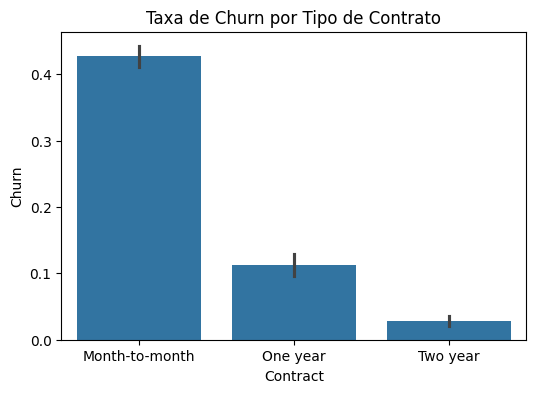

In [6]:

plt.figure(figsize=(6,4))
sns.barplot(x='Contract', y='Churn', data=df)
plt.title("Taxa de Churn por Tipo de Contrato")
plt.show()


**📊 Insight**

Contratos mensais apresentam maior churn, enquanto contratos de longo prazo tendem a reduzir cancelamentos.

### 📊 **5.2 Churn por Tipo de Internet**

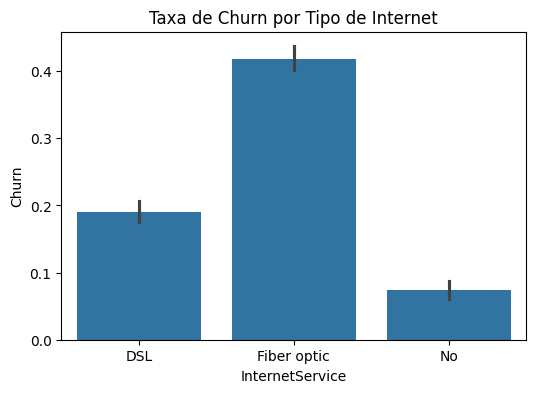

In [7]:

plt.figure(figsize=(6,4))
sns.barplot(x='InternetService', y='Churn', data=df)
plt.title("Taxa de Churn por Tipo de Internet")
plt.show()


**📊 Insight**

Clientes com **Fiber optic** apresentam maior taxa de churn,
enquanto usuários de **DSL ou sem internet** tendem a cancelar menos.

### 📊 **5.3 Distribuição do Tempo de Cliente**

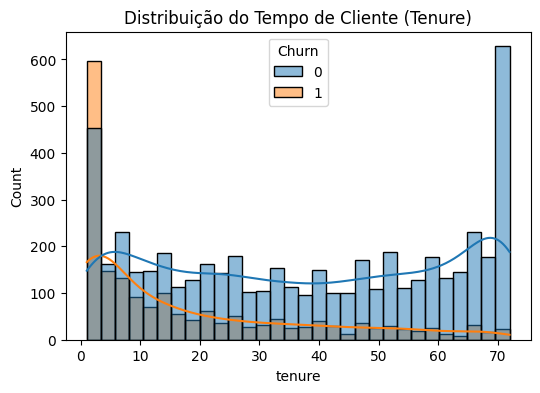

In [8]:

plt.figure(figsize=(6,4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title("Distribuição do Tempo de Cliente (Tenure)")
plt.show()


**📊 Insight**

A maior parte do churn ocorre entre clientes com pouco tempo de relacionamento,
indicando maior risco de cancelamento nos primeiros meses de contrato.

## 📈 **5.4 Análises Adicionais Comuns em Projetos de Churn**

### 1️⃣ Mensalidade vs Churn

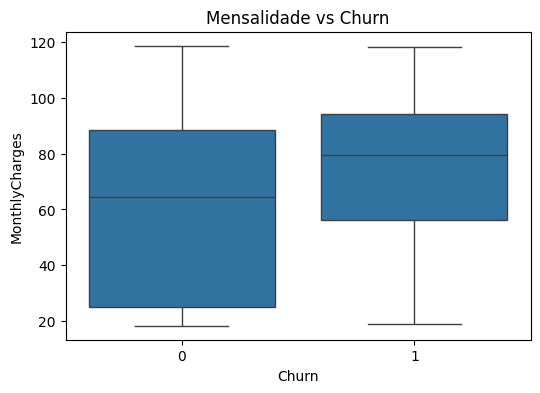

In [9]:

plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Mensalidade vs Churn")
plt.show()


**📊 Insight**

Clientes com mensalidades mais altas tendem a apresentar maior taxa de churn.

### 2️⃣ Churn por Faixa de Tenure

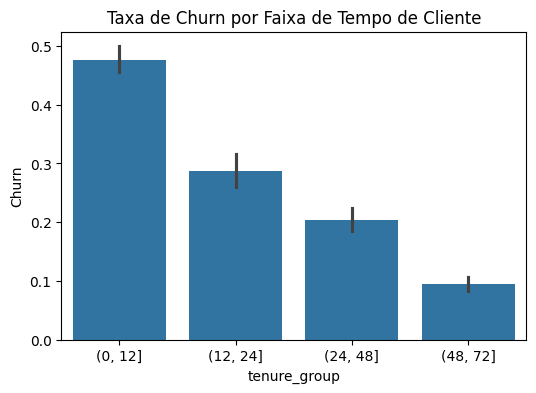

In [10]:

df['tenure_group'] = pd.cut(df['tenure'], bins=[0,12,24,48,72])

plt.figure(figsize=(6,4))
sns.barplot(x='tenure_group', y='Churn', data=df)
plt.title("Taxa de Churn por Faixa de Tempo de Cliente")
plt.show()


**📊 Insight**

A taxa de churn é maior nos primeiros meses de contrato e diminui
à medida que o tempo de relacionamento do cliente aumenta.

### 3️⃣ Impacto do Método de Pagamento

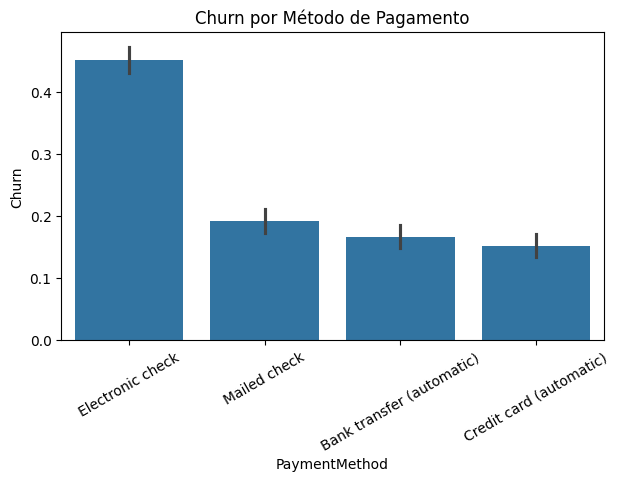

In [11]:

plt.figure(figsize=(7,4))
sns.barplot(x='PaymentMethod', y='Churn', data=df)
plt.xticks(rotation=30)
plt.title("Churn por Método de Pagamento")
plt.show()


**📊 Insight**

Clientes que pagam com **Electronic check** apresentam maior churn,
enquanto pagamentos automáticos tendem a reduzir cancelamentos.

## **6. Análise das Variáveis Categóricas**

In [12]:
impacto = {}

categoricas = df.select_dtypes(include='object').columns

for col in categoricas:
    
    taxas = df.groupby(col)['Churn'].mean()
    
    impacto[col] = taxas.max() - taxas.min()

impacto = pd.Series(impacto).sort_values(ascending=False)

print(impacto)

Contract            0.398610
InternetService     0.344586
OnlineSecurity      0.343445
TechSupport         0.342133
OnlineBackup        0.325075
DeviceProtection    0.317061
PaymentMethod       0.300323
StreamingMovies     0.262947
StreamingTV         0.261009
PaperlessBilling    0.172136
Dependents          0.157479
Partner             0.132590
MultipleLines       0.036485
PhoneService        0.017475
gender              0.007550
dtype: float64


**🔎 Explicação**

Quando a taxa de churn varia muito entre categorias de uma variável,
isso indica que ela possui relação com o cancelamento e pode ajudar
o modelo a prever churn.

**Exemplo:**

Se clientes com **contrato mensal** apresentam churn de **40%**
e clientes com **contrato de dois anos** apresentam churn de **10%**,
isso indica que o **tipo de contrato influencia o risco de cancelamento**.

## **7️. Seleção das Variáveis Categóricas Mais Relevantes**

In [13]:
impacto_forte = impacto[impacto >= 0.30]

print(impacto_forte)


Contract            0.398610
InternetService     0.344586
OnlineSecurity      0.343445
TechSupport         0.342133
OnlineBackup        0.325075
DeviceProtection    0.317061
PaymentMethod       0.300323
dtype: float64


**🔎 Explicação**

Aqui selecionamos apenas as variáveis categóricas com diferença de churn
maior ou igual a **30 pontos percentuais**, pois essa variação indica
forte influência no cancelamento dos clientes.

**Exemplo:** 

churn de **15% vs 50%** → diferença de **35 p.p.**, indicando alto impacto.

## 7.1 Remoção de Variável Redundante

In [14]:
df = df.drop(columns=['TotalCharges'], errors='ignore')

**🧹 Explicação**

**TotalCharges** é fortemente correlacionada com **tenure** e **MonthlyCharges**,
o que pode gerar **multicolinearidade**.  
Para evitar redundância no modelo, essa variável é removida.

## 🧩 **8. Criação das Variáveis do Modelo**

In [15]:
# variável alvo
y = df['Churn']

# variáveis numéricas
numericas = ['SeniorCitizen','tenure','MonthlyCharges']

df_num = df[numericas]

# variáveis categóricas selecionadas
categoricas_modelo = impacto_forte.index.tolist()

# criar dummies
df_cat = pd.get_dummies(
    df[categoricas_modelo],
    drop_first=True
)

# converter booleanos
bool_cols = df_cat.select_dtypes(include='bool').columns
df_cat[bool_cols] = df_cat[bool_cols].astype(int)

# dataset final do modelo
df_model = pd.concat([df_num, df_cat, y], axis=1)

df_model.head(5)



,SeniorCitizen,tenure,MonthlyCharges,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,TechSupport_No internet service,TechSupport_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,0,1,29.85,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0
1,0,34,56.95,1,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0
2,0,2,53.85,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,1
3,0,45,42.30,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0
4,0,2,70.70,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1


## ✂️ **8.1 Divisão Treino / Teste**

In [16]:
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

## 🤖 **8.2 Modelo de Regressão Logística**

In [17]:
modelo_ml = LogisticRegression(max_iter=1000)

modelo_ml.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

**⚙️ Preparação do Modelo**

A variável **Churn** é definida como alvo e as variáveis categóricas são
convertidas em **dummies**.  
Os dados são divididos em **treino (70%)** e **teste (30%)**, e o modelo
de **Regressão Logística** é então treinado.

## 📊 **8.3 Avaliação do Modelo**

In [18]:
y_pred = modelo_ml.predict(X_test)

print("Acurácia do modelo:", accuracy_score(y_test, y_pred))

print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred))


Acurácia do modelo: 0.7924170616113744

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1549
           1       0.63      0.52      0.57       561

    accuracy                           0.79      2110
   macro avg       0.74      0.71      0.72      2110
weighted avg       0.78      0.79      0.79      2110



**📊 Interpretação dos Resultados**

O modelo apresenta **acurácia de ~80%**, com melhor desempenho para prever
clientes que **não cancelam** do que para identificar clientes que **cancelam**,
o que é esperado devido ao **desbalanceamento do dataset**.

## 🔀 **9. Matriz de Confusão**

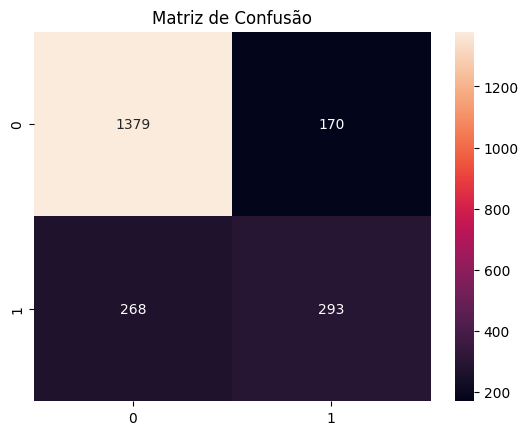

In [19]:

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Matriz de Confusão")
plt.show()

**📊 Interpretação da Matriz de Confusão**

**A matriz de confusão mostra quantas previsões foram corretas e incorretas.**

O modelo identificou **293 de 561 clientes que cancelaram**, o que corresponde
a aproximadamente **52% dos churns reais**.
Esse resultado ocorre em parte porque o dataset é **desbalanceado**,
com mais clientes que permanecem do que clientes que cancelam.

Por isso, o modelo tende a prever com maior facilidade a **classe majoritária
(não churn)**, reduzindo sua capacidade de identificar todos os casos de churn.

*Isso indica oportunidade para técnicas de tratamento de desbalanceamento, como class weights, oversampling ou ajuste do threshold*

## 📈 **10. Curva ROC**

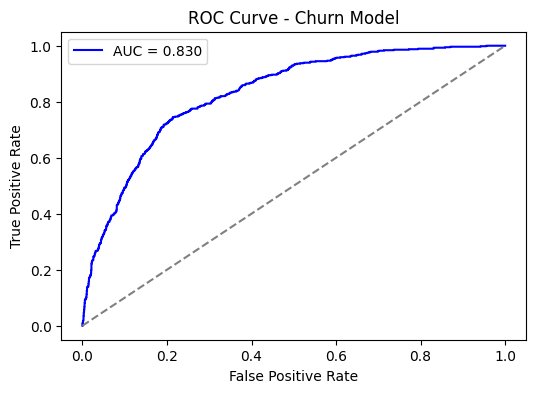

In [24]:
plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}", color="blue")

plt.plot([0,1],[0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Churn Model")

plt.legend()

plt.show()

**📈 Interpretação da Curva ROC**

A curva ROC mede a capacidade do modelo de distinguir entre churn e não churn.
Um **AUC = 0.830** indica boa capacidade de separação entre clientes
que cancelam e os que permanecem.

## 🔮**11. Teste de Previsão para Novos Clientes**

Nesta etapa simulamos a previsão de churn para novos clientes utilizando
o modelo treinado. Criamos dois perfis hipotéticos de clientes com
características diferentes para observar como o modelo estima a
probabilidade de cancelamento.

O primeiro exemplo representa um cliente com características associadas
a **maior risco de churn**, enquanto o segundo representa um cliente
com características associadas a **maior retenção**.

**🔴 Cliente problemático**

In [28]:
novo_cliente = pd.DataFrame({

    'SeniorCitizen':[0],
    'tenure':[12],
    'MonthlyCharges':[70],

    'Contract_One year':[0],
    'Contract_Two year':[0],

    'InternetService_Fiber optic':[1],
    'InternetService_No':[0],

    'TechSupport_Yes':[0],

    'PaymentMethod_Credit card (automatic)':[0],
    'PaymentMethod_Electronic check':[1],
    'PaymentMethod_Mailed check':[0]

})

# garantir mesmas colunas do modelo
novo_cliente = novo_cliente.reindex(columns=X_train.columns, fill_value=0)

previsao = modelo_ml.predict(novo_cliente)

probabilidade = modelo_ml.predict_proba(novo_cliente)[0][1]

print("Previsão de churn:", previsao[0])
print("Probabilidade de churn:", probabilidade)

Previsão de churn: 1
Probabilidade de churn: 0.6294849018375667


**💡 Insight**

Clientes com **contrato mensal, baixo tenure e sem suporte técnico**
apresentam maior probabilidade de churn.

**🟢 Segundo cliente (baixo risco)**

In [22]:
cliente_estavel = pd.DataFrame({

    'SeniorCitizen':[0],
    'tenure':[60],
    'MonthlyCharges':[50],

    'Contract_One year':[0],
    'Contract_Two year':[1],

    'InternetService_Fiber optic':[0],
    'InternetService_No':[0],

    'TechSupport_Yes':[1],

    'PaymentMethod_Credit card (automatic)':[1],
    'PaymentMethod_Electronic check':[0],
    'PaymentMethod_Mailed check':[0]

})

cliente_estavel = cliente_estavel.reindex(columns=X_train.columns, fill_value=0)

previsao = modelo_ml.predict(cliente_estavel)
probabilidade = modelo_ml.predict_proba(cliente_estavel)

print("Previsão de churn:", previsao[0])
print("Probabilidade de churn:", probabilidade[0][1])

Previsão de churn: 0
Probabilidade de churn: 0.01900021249906216


**💡 Insight**

Clientes com **tenure alto, contrato de longo prazo e suporte técnico**
tendem a apresentar menor probabilidade de churn.

---


# 💼 Insights de Negócio

A análise exploratória e o modelo revelam alguns padrões importantes:

### Clientes com maior risco de churn
- Contratos mensais
- Internet fibra óptica
- Clientes sem suporte técnico
- Clientes novos (baixo tenure)
- Mensalidades mais altas

### Clientes com menor risco de churn
- Contratos de longo prazo (1 ou 2 anos)
- Clientes com suporte técnico
- Clientes com mais tempo de relacionamento

---

## Estratégias possíveis de retenção

Empresas poderiam:

- Incentivar **contratos de longo prazo**
- Oferecer **suporte técnico gratuito para novos clientes**
- Criar **programas de fidelidade**
- Monitorar clientes com **mensalidades elevadas**



# ✅ Conclusão

Este projeto demonstrou como aplicar **Regressão Logística para prever churn de clientes**.

Principais resultados:

✔ Modelo com **boa capacidade preditiva (AUC ~0.82)**  
✔ Identificação de **fatores associados ao cancelamento**  
✔ Geração de **insights estratégicos para retenção**

Mesmo modelos relativamente simples podem gerar **grande valor de negócio quando combinados com análise exploratória e interpretação correta**.


